# Day 11: Multiobjective Optimization Examples

---


# Setup



In [1]:
# Core libraries
import pandas as pd
import grama as gr
DF = gr.Intention()


We define a simple function with a non-convex Pareto frontier

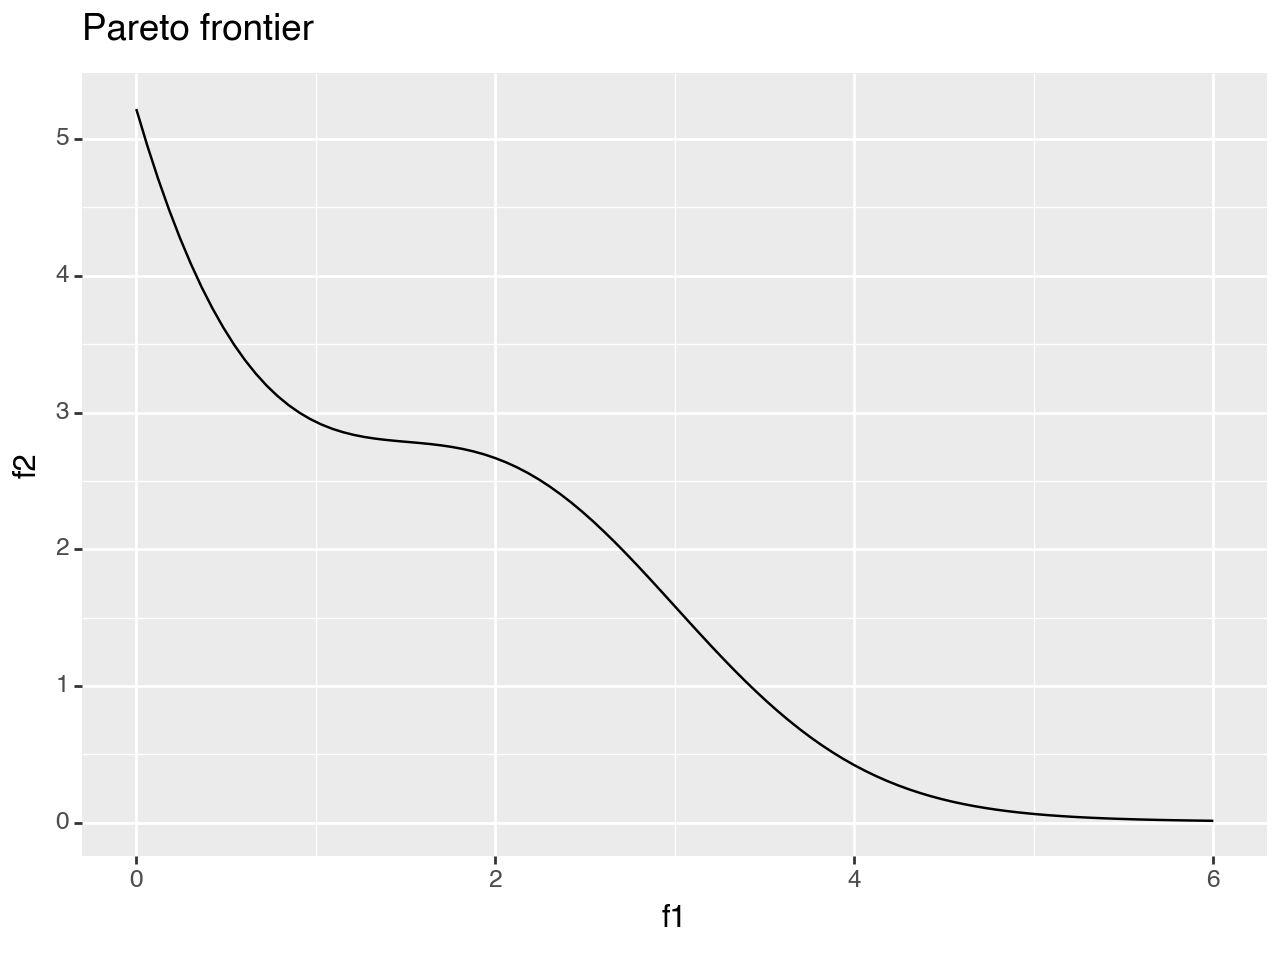

<Figure Size: (640 x 480)>

In [2]:
md = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df: df
        >> gr.tf_mutate(
            f1=df.x,
            f2=5*gr.exp(-df.x) + 2*gr.exp(-0.5*(df.x - 2.1)**2),
        ),
        var=["x"],
        out=["f1", "f2"],
    )
    >> gr.cp_bounds(x=(0, 6))
)

df_frontier = (
    md
    >> gr.ev_df(df=gr.df_make(x=gr.linspace(0, 6, 100)))
)

(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line()
    + gr.labs(
        title="Pareto frontier"
    )
)

## Lexicographic method

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


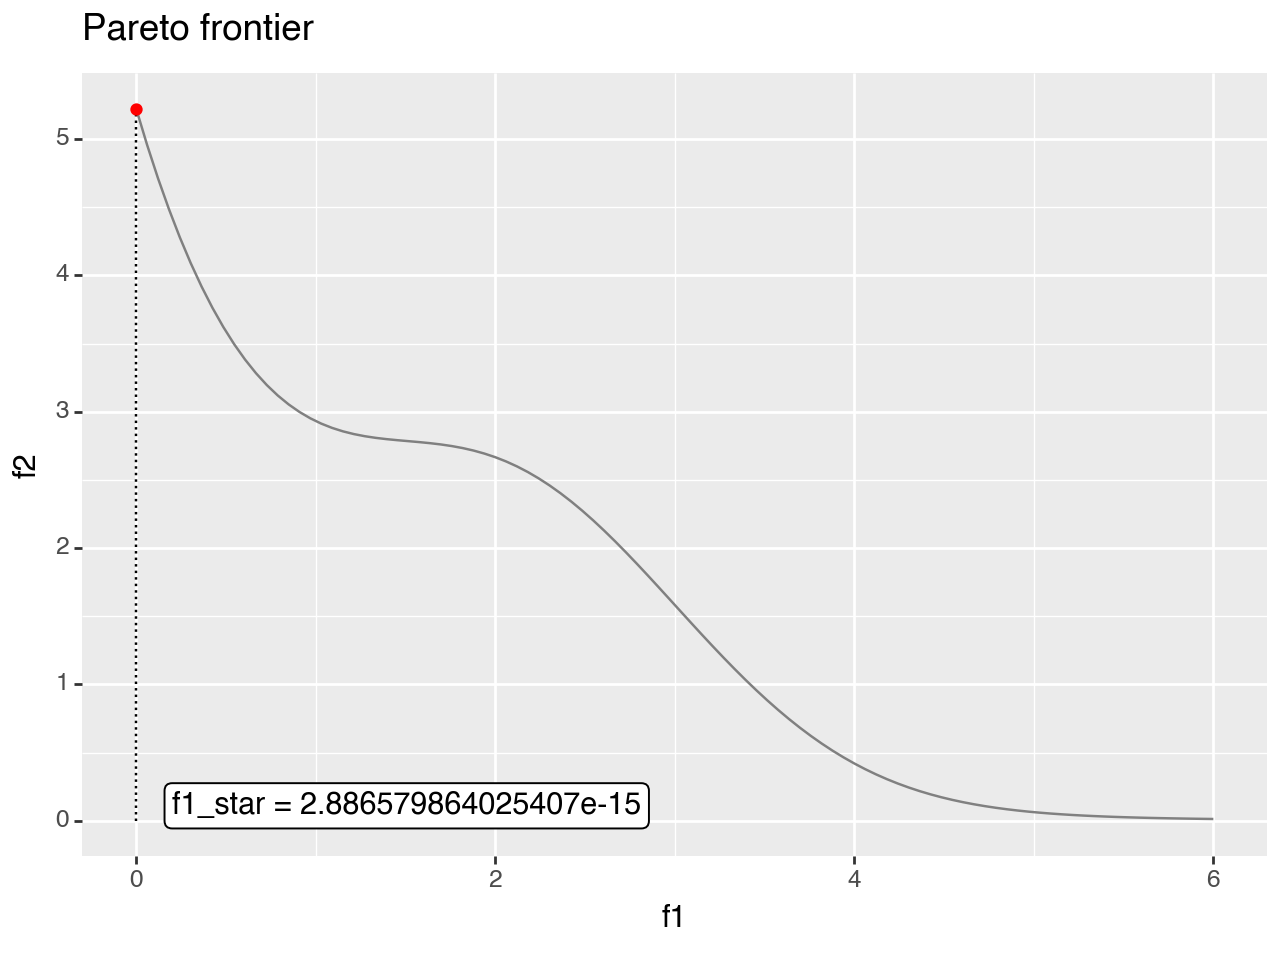

<Figure Size: (640 x 480)>

In [3]:
# First, optimize f1 ignoring f2
df_f1_opt = (
    md
    >> gr.ev_min(out_min="f1")
)
f1_star = df_f1_opt.f1[0]
# Next, optimize f2, constraining f1 <= f1_star
df_f2_opt = (
    md
    # Add a new function to get f1 <= f1_star in standard form
    >> gr.cp_vec_function(
        fun=lambda df: df >> gr.tf_mutate(g=df.f1 - f1_star),
        var=["f2"],
        out=["g"],
    )
    >> gr.ev_min(out_min="f1", out_leq=["g"])
)

# Visualize the result
(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line(color="grey")
    + gr.geom_segment(
        data=df_f2_opt
        >> gr.tf_mutate(x0=f1_star, y0=0),
        mapping=gr.aes(x="x0", y="y0", xend="f1", yend="f2"),
        linetype="dotted",
    )
    + gr.annotate(
        "label",
        x=f1_star+0.2, y=0,
        label="f1_star = {}".format(f1_star),
        ha="left", va="bottom",
    )
    + gr.geom_point(data=df_f2_opt, color="red")
    + gr.labs(
        title="Pareto frontier"
    )

)

Note that we can't "sweep" the Pareto frontier using the Lexicographic method; we simply rank the objectives and optimize them in that sequence.


## Constraint method

Estimated runtime: 0.0000 sec


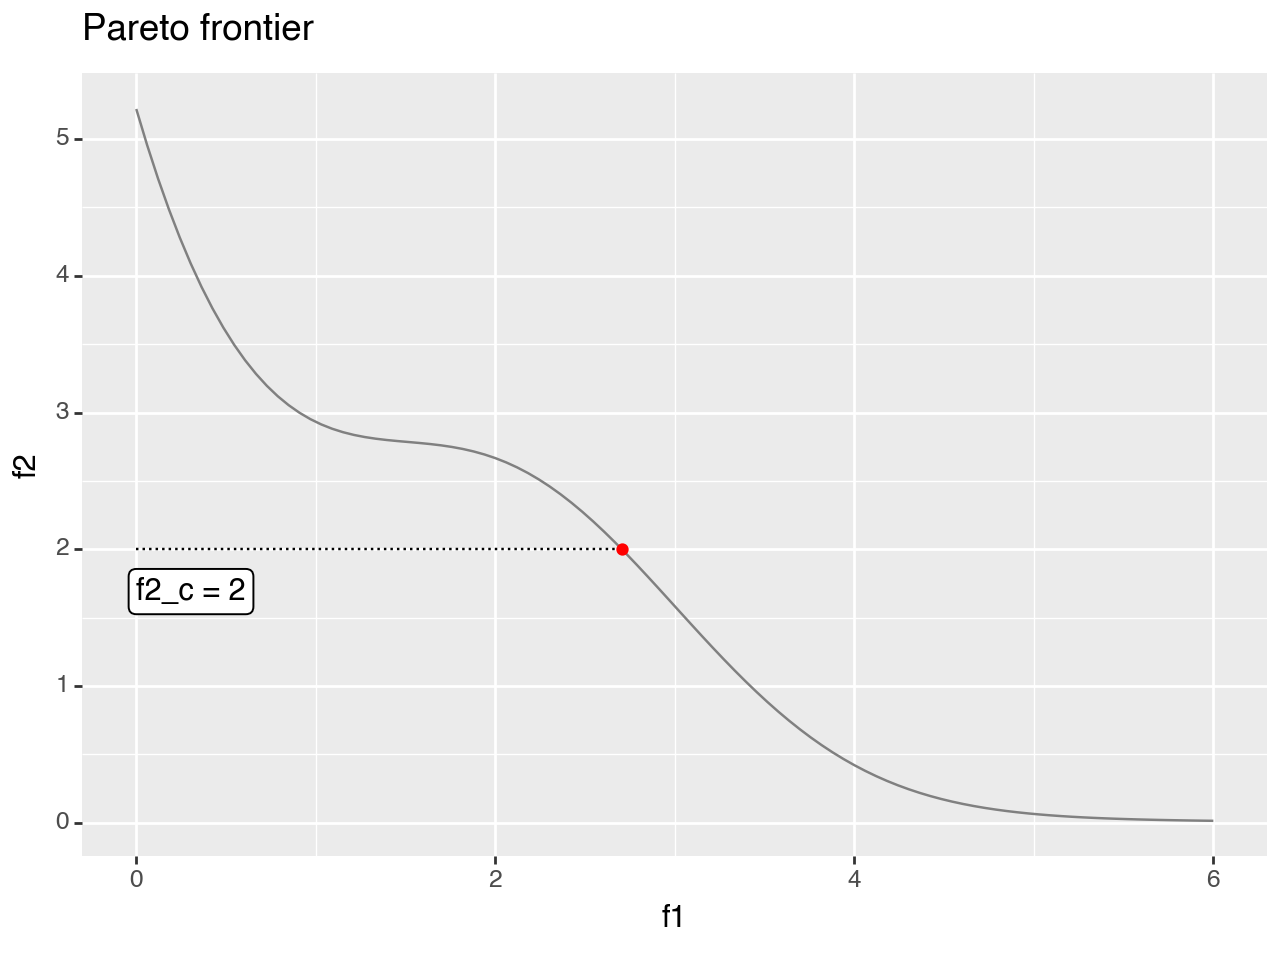

<Figure Size: (640 x 480)>

In [4]:
# Set constraint value for f2
f2_c = 2

# Optimize f1 using f2 <= f2_c
df_res = (
    md
    # Add a new function to get f2 <= f2_c in standard form
    >> gr.cp_vec_function(
        fun=lambda df: df >> gr.tf_mutate(g=df.f2 - f2_c),
        var=["f2"],
        out=["g"],
    )
    >> gr.ev_min(
        out_min="f1",
        out_leq=["g"],
    )
)

# Visualize the result
(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line(color="grey")
    + gr.geom_segment(
        data=df_res
        >> gr.tf_mutate(x0=0, y0=f2_c),
        mapping=gr.aes(x="x0", y="y0", xend="f1", yend="f2"),
        linetype="dotted",
    )
    + gr.annotate(
        "label",
        x=0, y=f2_c-0.2,
        label="f2_c = {}".format(f2_c),
        ha="left", va="top",
    )
    + gr.geom_point(data=df_res, color="red")
    + gr.labs(
        title="Pareto frontier"
    )

)

### Sweeping the frontier

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


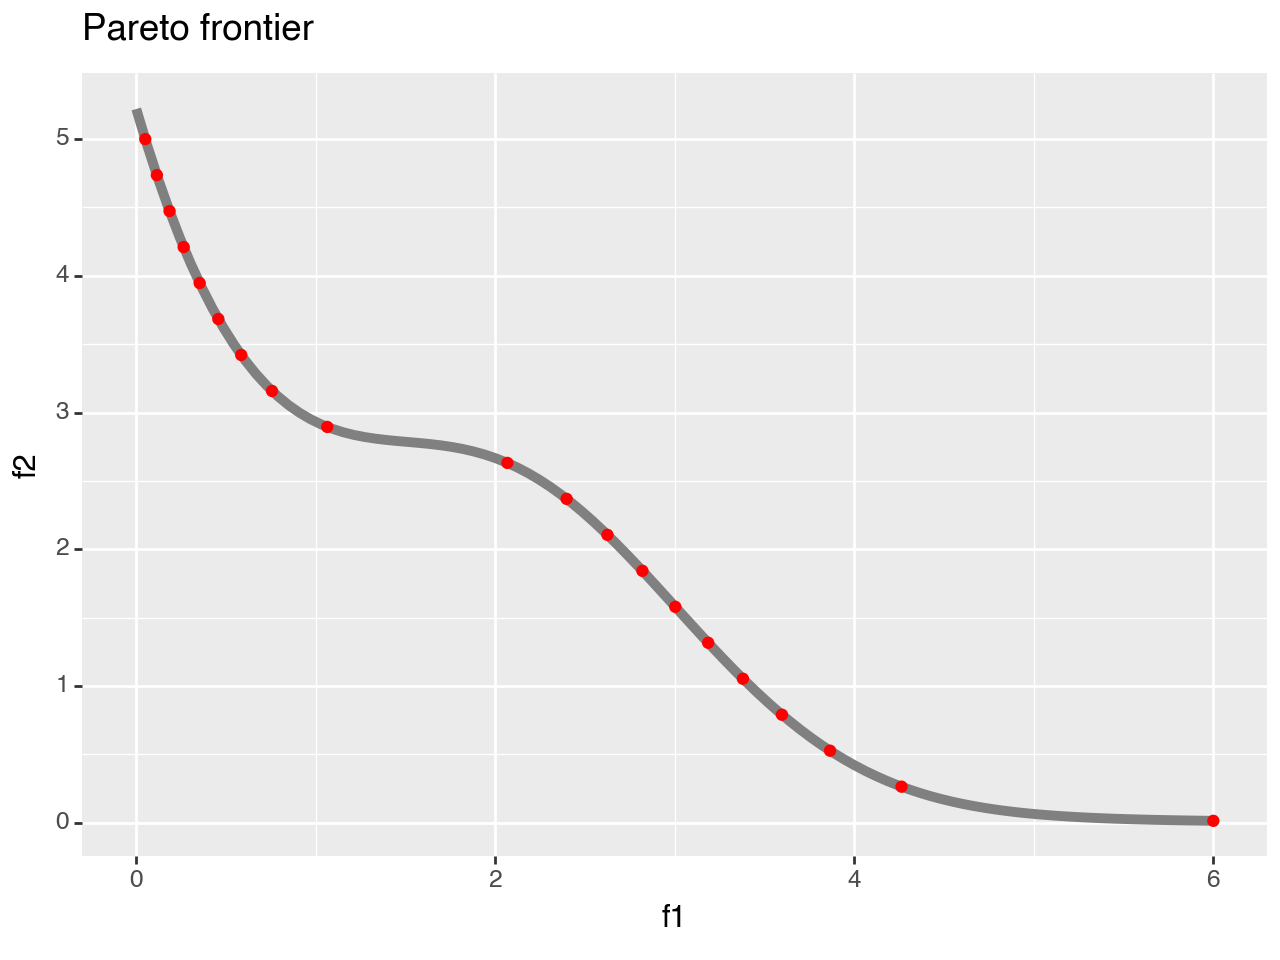

<Figure Size: (640 x 480)>

In [5]:
df_res = gr.df_grid()
f2_c_all = gr.linspace(0, 5, 20)

for c in f2_c_all:
    df_tmp = (
        md
        # Add a new function to get f2 <= c in standard form
        >> gr.cp_vec_function(
            fun=lambda df: df >> gr.tf_mutate(g=df.f2 - c),
            var=["f2"],
            out=["g"],
        )
        # Optimize f1 using f2 <= c
        >> gr.ev_min(
            out_min="f1",
            out_leq=["g"],
        )
    )
    # Append the results
    df_res = (
        df_res
        >> gr.tf_bind_rows(df_tmp)
    )

# Visualize the result
(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line(color="grey", size=2)
    + gr.geom_point(data=df_res, color="red")
    + gr.labs(
        title="Pareto frontier"
    )
)

## Weight method


Estimated runtime: 0.0000 sec


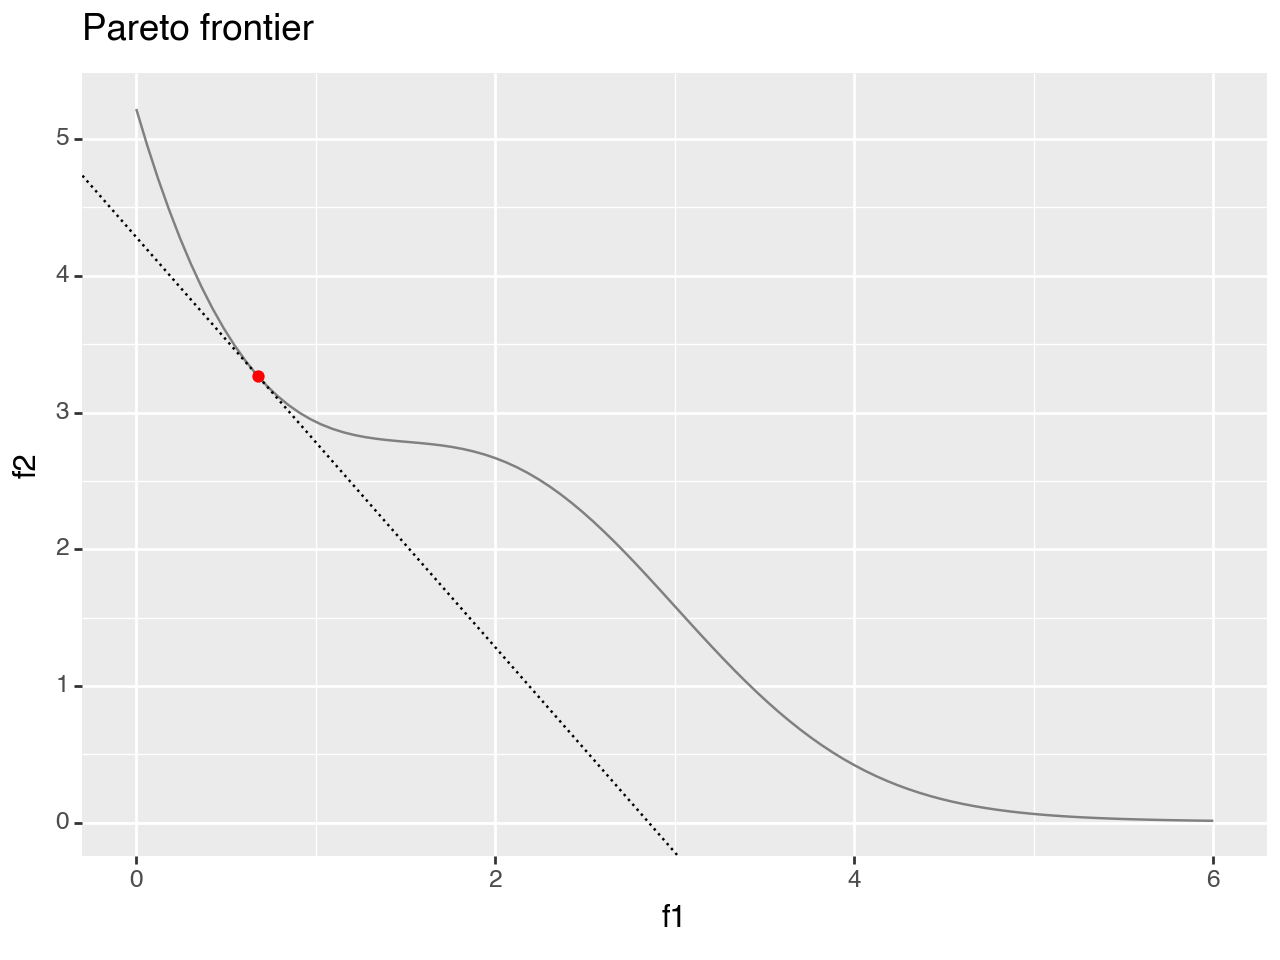

<Figure Size: (640 x 480)>

In [6]:
# Set weights for scalarization
c2 = 0.4
c1 = 1 - c2

# Optimize single objective c1*f1 + c2*f2
df_res = (
    md
    # Add a new function to represent c1*f1 + c2*f2
    >> gr.cp_vec_function(
        fun=lambda df: df >> gr.tf_mutate(f=c1*df.f1 + c2*df.f2),
        var=["f1", "f2"],
        out=["f"],
    )
    >> gr.ev_min(
        out_min="f",
    )
)

# Find tangent line parameters
slope = -c1 / c2
intercept = df_res.f2[0] - slope * df_res.f1[0]

# Visualize the result
(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line(color="grey")
    + gr.geom_abline(
        slope=slope,
        intercept=intercept,
        linetype="dotted",
    )
    + gr.geom_point(data=df_res, color="red")
    + gr.labs(
        title="Pareto frontier"
    )

)

### Sweeping the frontier

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


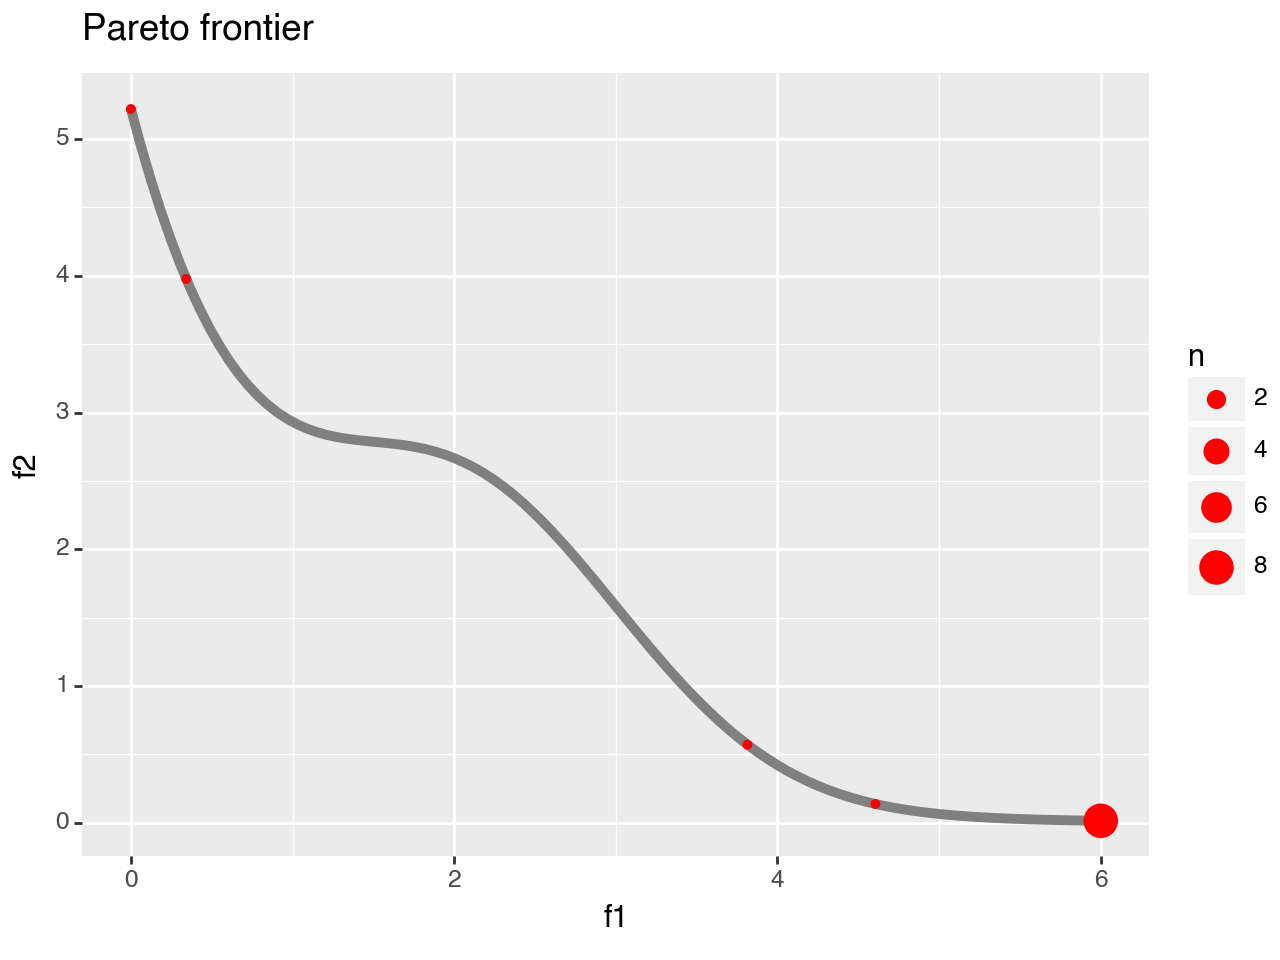

<Figure Size: (640 x 480)>

In [7]:
df_res = gr.df_grid()
c2_all = gr.linspace(0, 1, 20)

for c2 in f2_c_all:
    # Set weights for scalarization
    c1 = 1 - c2
    
    # Optimize single objective c1*f1 + c2*f2
    df_tmp = (
        md
        # Add a new function to represent c1*f1 + c2*f2
        >> gr.cp_vec_function(
            fun=lambda df: df >> gr.tf_mutate(f=c1*df.f1 + c2*df.f2),
            var=["f1", "f2"],
            out=["f"],
        )
        >> gr.ev_min(
            out_min="f",
        )
    )
    # Append the results
    df_res = (
        df_res
        >> gr.tf_bind_rows(df_tmp)
    )

# Visualize the result
(
    df_frontier
    >> gr.ggplot(gr.aes("f1", "f2"))
    + gr.geom_line(color="grey", size=2)
    + gr.geom_count(data=df_res, color="red")
    + gr.labs(
        title="Pareto frontier"
    )
)